In [1]:
from datetime import datetime

print(f"Timestamp: {datetime.now()}")

Timestamp: 2026-01-23 16:39:17.373372


# Project Xenium Signature to Sequencing Data

**Pinned Environment:** [`envs/sc-scvi.yaml`](../.../envs/sc-scvi.yaml)  

In [4]:
from pathlib import Path
import os
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import matplotlib.pyplot as plt
import matplotlib.lines as mlines
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
from scipy import sparse
import warnings
import session_info
import sys

In [5]:
plt.rcParams['figure.figsize'] = (3, 3)
plt.rcParams['figure.dpi'] = 150

### Setup

In [6]:
# base_dir = '/home/workspace/private/projects/kim/drg'
# panel_dir = os.path.join(base_dir, 'panel/gene-lists/drafts')
# adata_path = os.path.join(base_dir, 'data/scrna-seq/h5ad/04_clustered/GSE139088-scvi-leiden.h5ad')

base_dir = "/home/workspace/DRG"
data_dir = "sc-spatial-gpu-ide_transer/projects/20260115_drg-gpu-backup"

input_dir = os.path.join(base_dir, data_dir, "data/h5ad/export_04/04c_gamma_subtypes")
output_dir = os.path.join(base_dir, "spatial_mouse_drg_outputs/Kim/update_thresholds_method2b")

plot_out_dir = os.path.join(output_dir, "plots")

adata_path = "/home/workspace/DRG/MC_private_folder/home/workspace/private/projects/kim/drg/data/scrna-seq/h5ad/04_clustered/GSE139088-scvi-leiden.h5ad"

In [7]:
adata = sc.read_h5ad(adata_path)

In [10]:
# is data scaled (has negatives)?
(adata.X < 0).sum()

0

In [13]:
# is data log norm?
adata.X[0:100,0:100]

array([[0., 4., 0., ..., 0., 0., 0.],
       [2., 2., 1., ..., 0., 0., 0.],
       [0., 2., 1., ..., 0., 0., 0.],
       ...,
       [2., 1., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.],
       [1., 0., 0., ..., 0., 0., 0.]])

In [31]:
from scipy.sparse import issparse

layer_check = 'log1p'

# Get the actual values without expanding the sparse matrix
# vals = adata.X.data if issparse(adata.X) else adata.X
vals = adata.layers[layer_check] if issparse(adata.layers[layer_check]) else adata.layers[layer_check]

# 1. Check for Scaled Data (Negatives)
has_negatives = np.any(vals < 0)

# 2. Check for Integers (Counts)
# We check if the remainder of all values divided by 1 is zero
is_integer = np.all(vals % 1 == 0)

# Identify the state
if has_negatives:
    print(layer_check, " Matrix is SCALED (Z-scored). Contains decimals and negatives.")
elif is_integer:
    print(layer_check, " Matrix is RAW COUNTS. Contains only integers >= 0.")
else:
    print(layer_check, " Matrix is LOG-NORMALIZED. Contains decimals >= 0.")

print(np.min(vals))
print(np.max(vals))

log1p  Matrix is LOG-NORMALIZED. Contains decimals >= 0.
0.0
11.30548718169177


In [33]:
from scipy.sparse import issparse

layer_check = 'counts'

# Get the actual values without expanding the sparse matrix
# vals = adata.X.data if issparse(adata.X) else adata.X
vals = adata.layers[layer_check] if issparse(adata.layers[layer_check]) else adata.layers[layer_check]

# 1. Check for Scaled Data (Negatives)
has_negatives = np.any(vals < 0)

# 2. Check for Integers (Counts)
# We check if the remainder of all values divided by 1 is zero
is_integer = np.all(vals % 1 == 0)

# Identify the state
if has_negatives:
    print(layer_check, " Matrix is SCALED (Z-scored). Contains decimals and negatives.")
elif is_integer:
    print(layer_check, " Matrix is RAW COUNTS. Contains only integers >= 0.")
else:
    print(layer_check, " Matrix is LOG-NORMALIZED. Contains decimals >= 0.")

print(np.min(vals))
print(np.max(vals))

counts  Matrix is RAW COUNTS. Contains only integers >= 0.
0.0
1291.0


In [32]:
# Get the actual values without expanding the sparse matrix
# vals = adata.X.data if issparse(adata.X) else adata.X
vals = adata.X if issparse(adata.X) else adata.X

# 1. Check for Scaled Data (Negatives)
has_negatives = np.any(vals < 0)

# 2. Check for Integers (Counts)
# We check if the remainder of all values divided by 1 is zero
is_integer = np.all(vals % 1 == 0)

# Identify the state
if has_negatives:
    print( ".X Matrix is SCALED (Z-scored). Contains decimals and negatives.")
elif is_integer:
    print(".X Matrix is RAW COUNTS. Contains only integers >= 0.")
else:
    print( ".X Matrix is LOG-NORMALIZED. Contains decimals >= 0.")

print(np.min(vals))
print(np.max(vals))

.X Matrix is RAW COUNTS. Contains only integers >= 0.
0.0
1291.0


## Reset adata.X to log1p

In [34]:
adata.X = adata.layers['log1p'].copy()

In [35]:
# palette for label plotting
import pickle
with open(os.path.join(output_dir, 'neuron_label_palette_mapped_ginty.pkl'), 'rb') as f:
    neuron_label_palette_mapped_ginty = pickle.load(f)

In [36]:
genes = ['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b',
         'Piezo2', 'Ctcflos', 'Adra2a', 'Chrnb4', 'Chrna3', 'Trpv1', 'Asic3', 'Kcnq3',
        'original_annotation']

In [37]:
adata

AnnData object with n_obs × n_vars = 10729 × 20924
    obs: 'original_annotation', 'GSE', 'GSM', 'sample_number', 'sample_id', 'experiment_id', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'total_counts_ribosomal', 'pct_counts_ribosomal', 'doublet_scores', 'predicted_doublets', '_scvi_batch', '_scvi_labels', 'leiden'
    var: 'mt', 'ribosomal', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts'
    uns: '_scvi_manager_uuid', '_scvi_uuid', 'leiden', 'leiden_colors', 'log1p', 'neighbors', 'original_annotation_colors', 'rank_genes_groups', 'sample_id_colors', 'umap'
    obsm: 'X_scVI', 'X_umap'
    layers: 'counts', 'log1p', 'normalized_1e6'
    obsp: 'connectivities', 'distances'

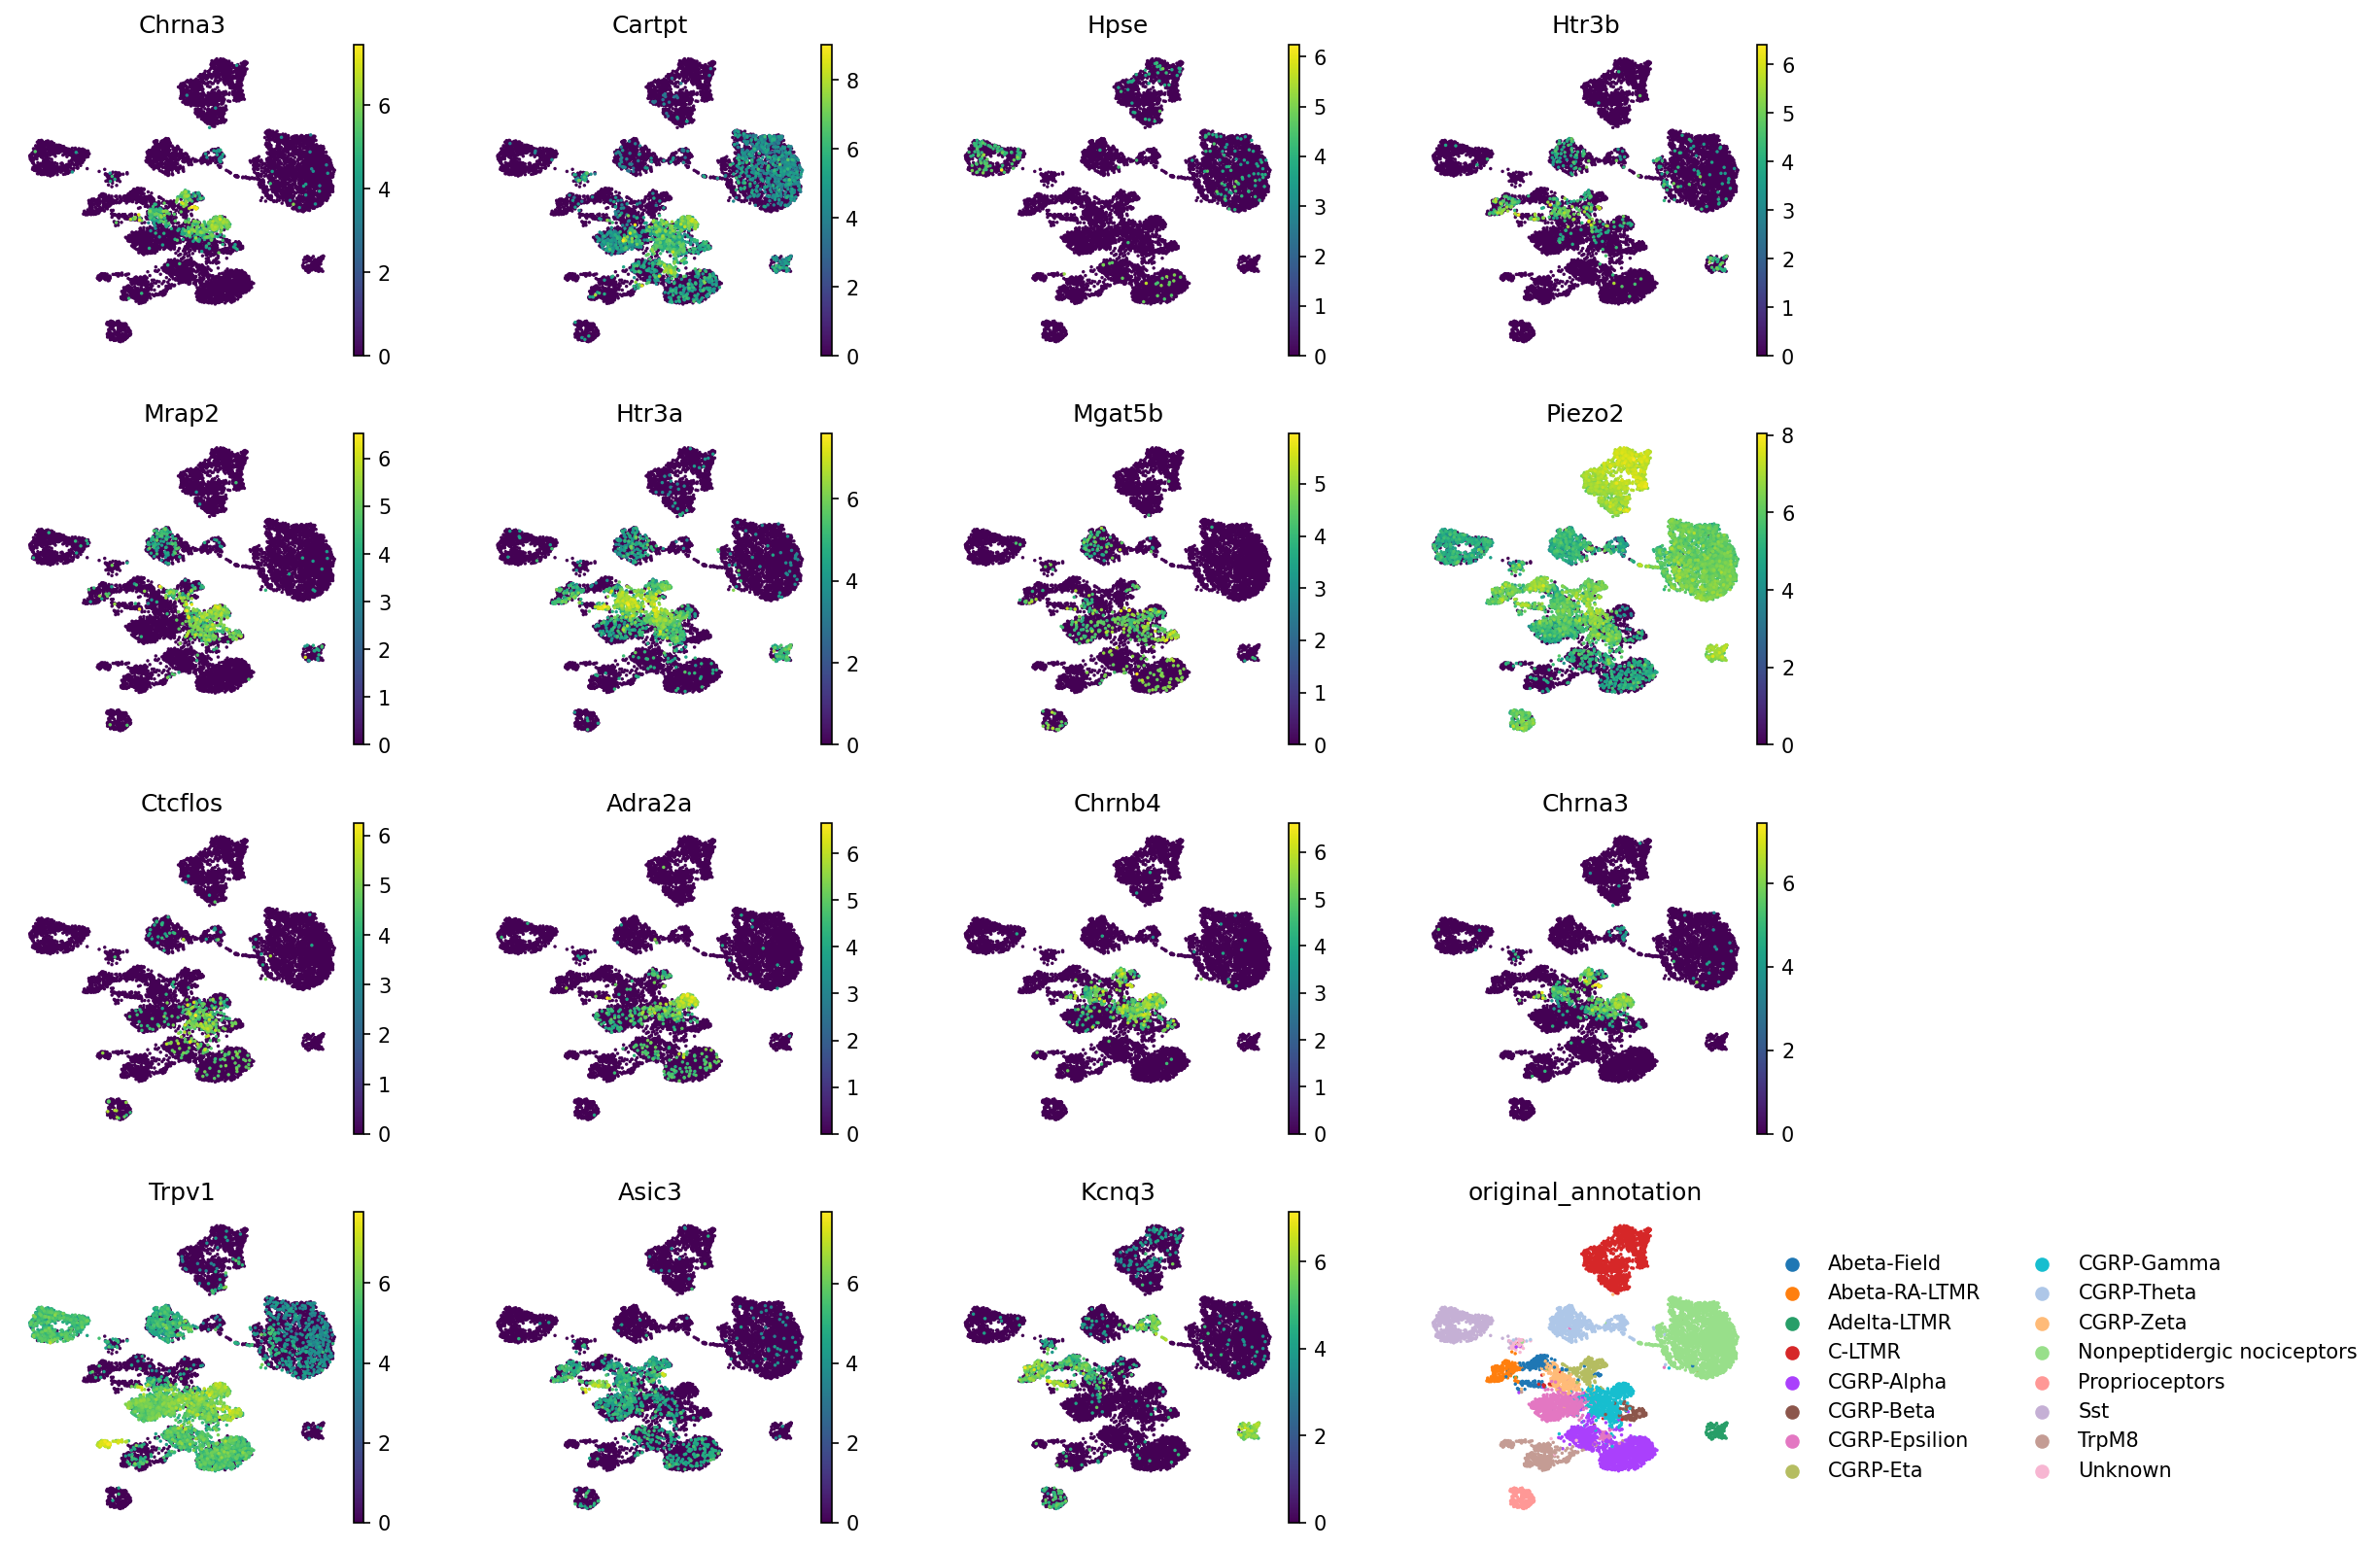

In [38]:
sc.pl.umap(adata, color = genes, frameon = False)

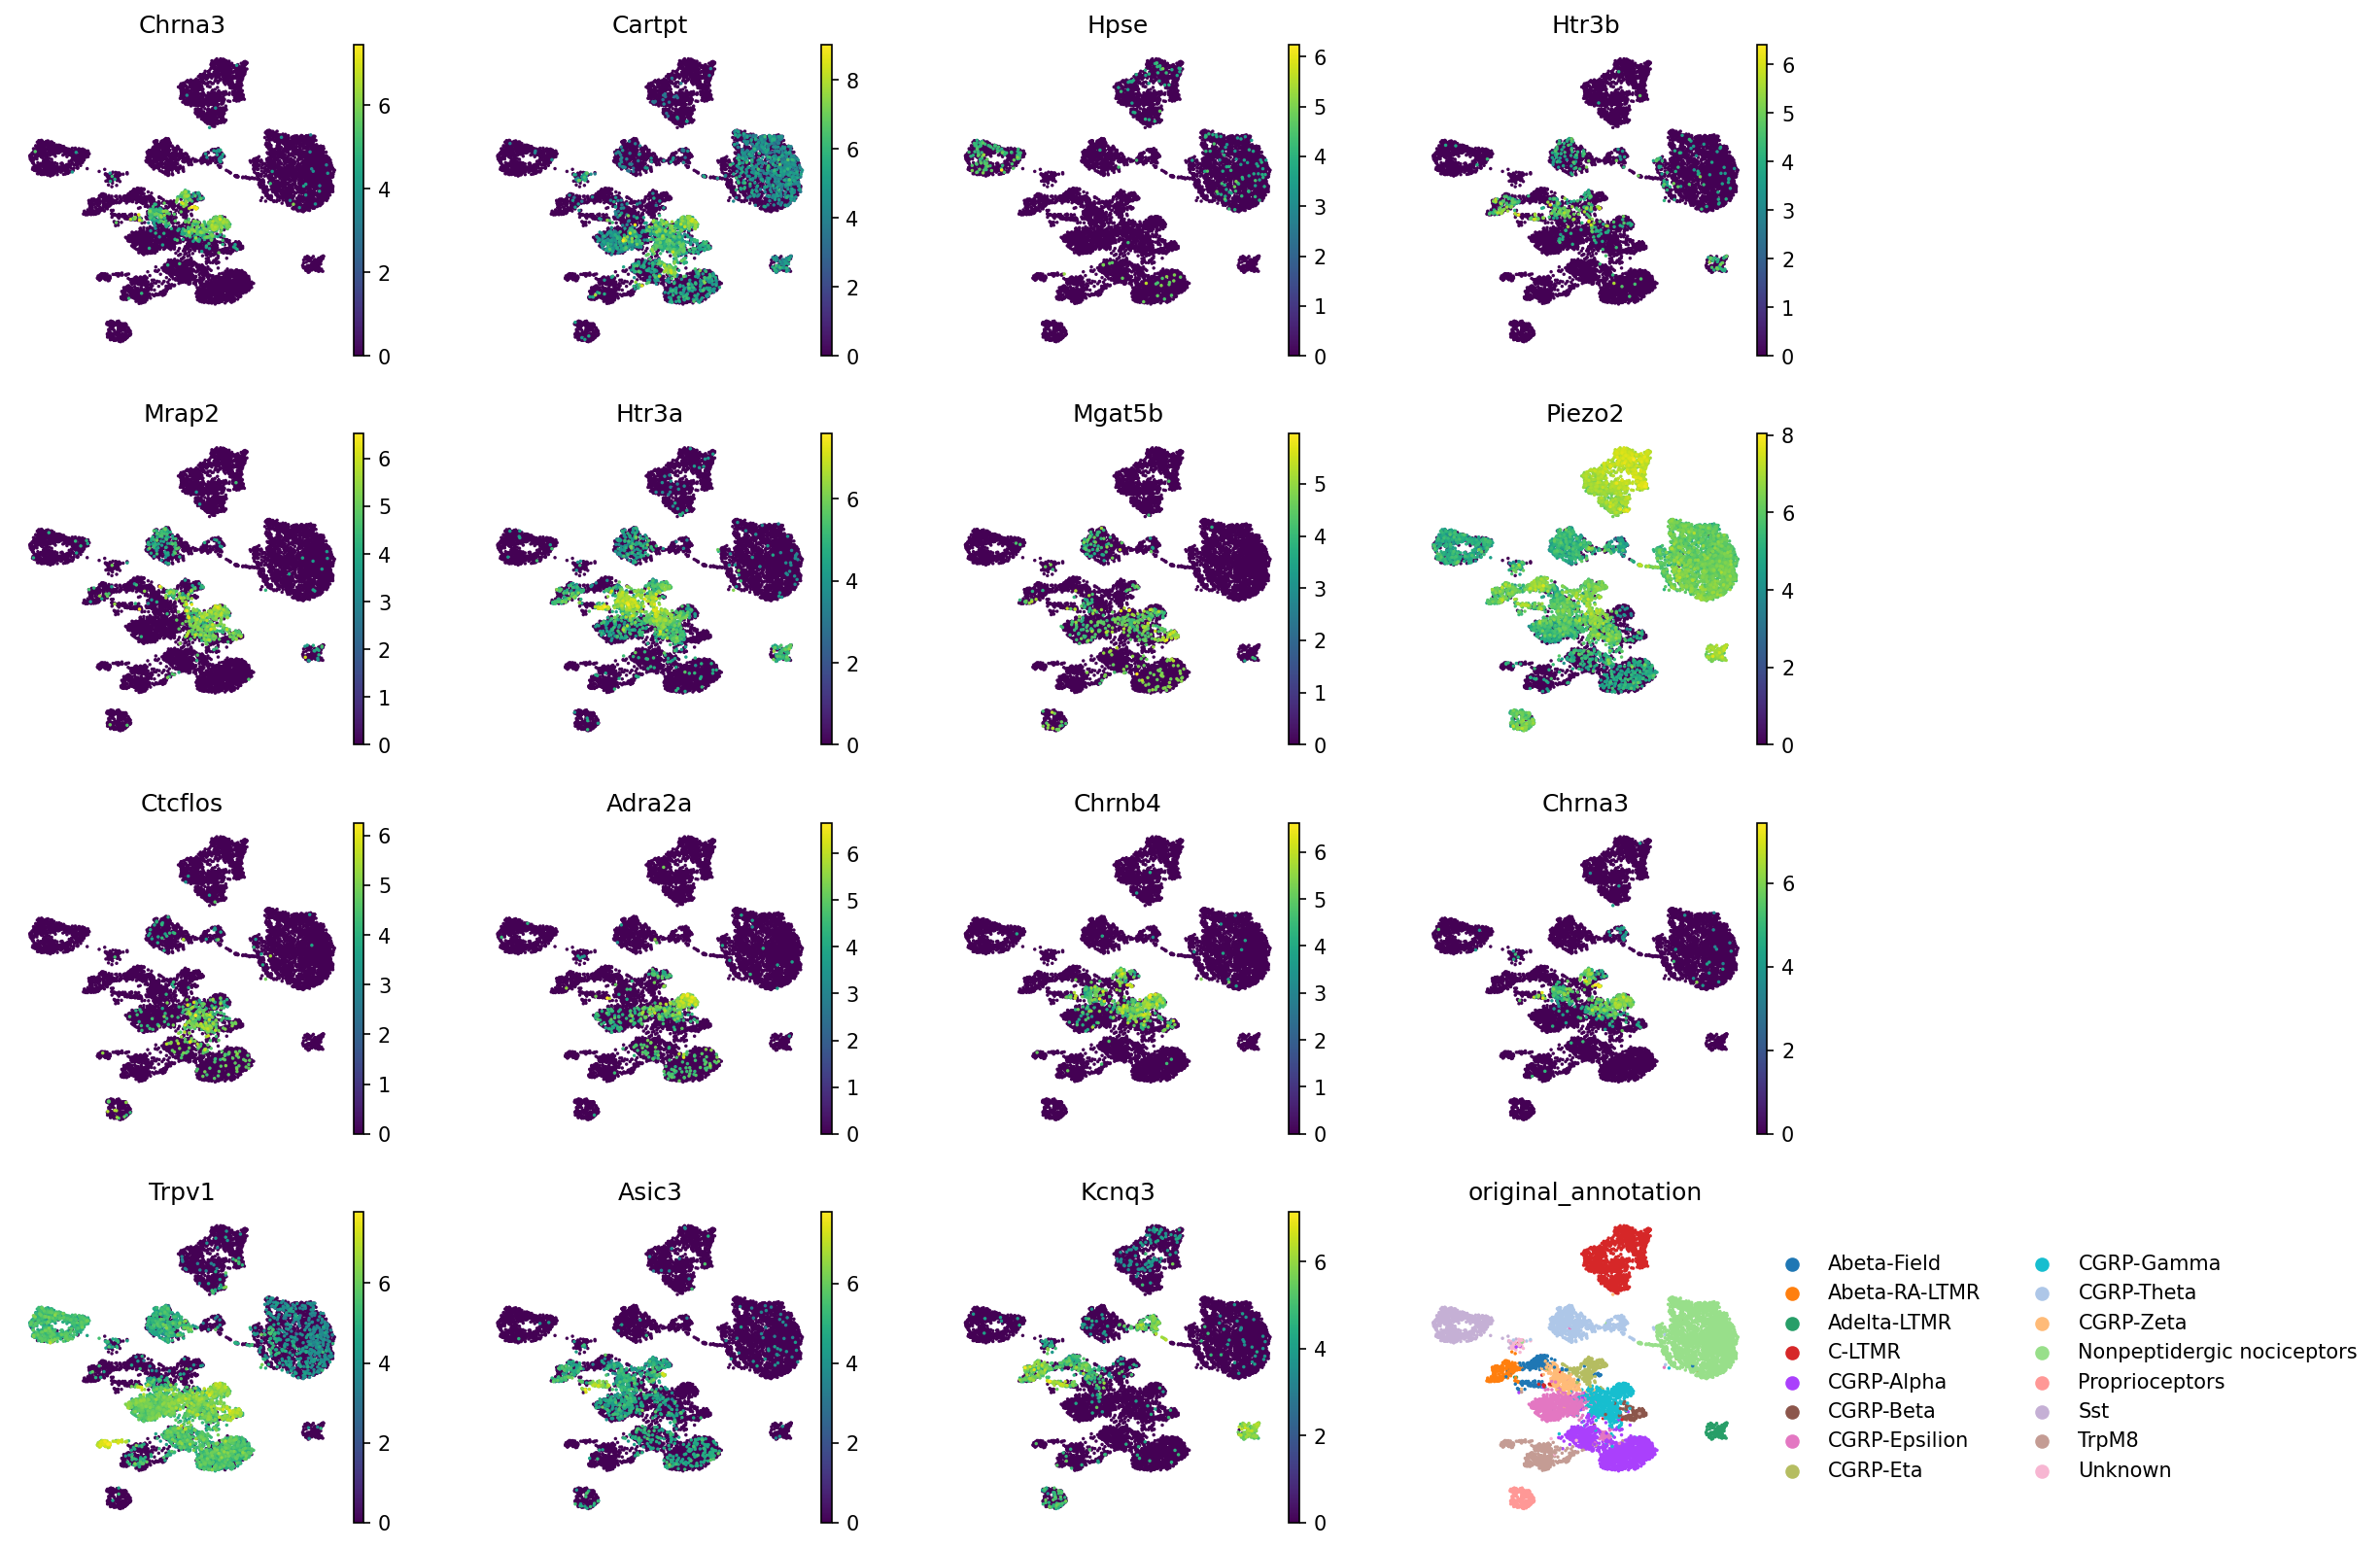

In [39]:
sc.pl.umap(adata, color = genes, layer = 'log1p', frameon = False)

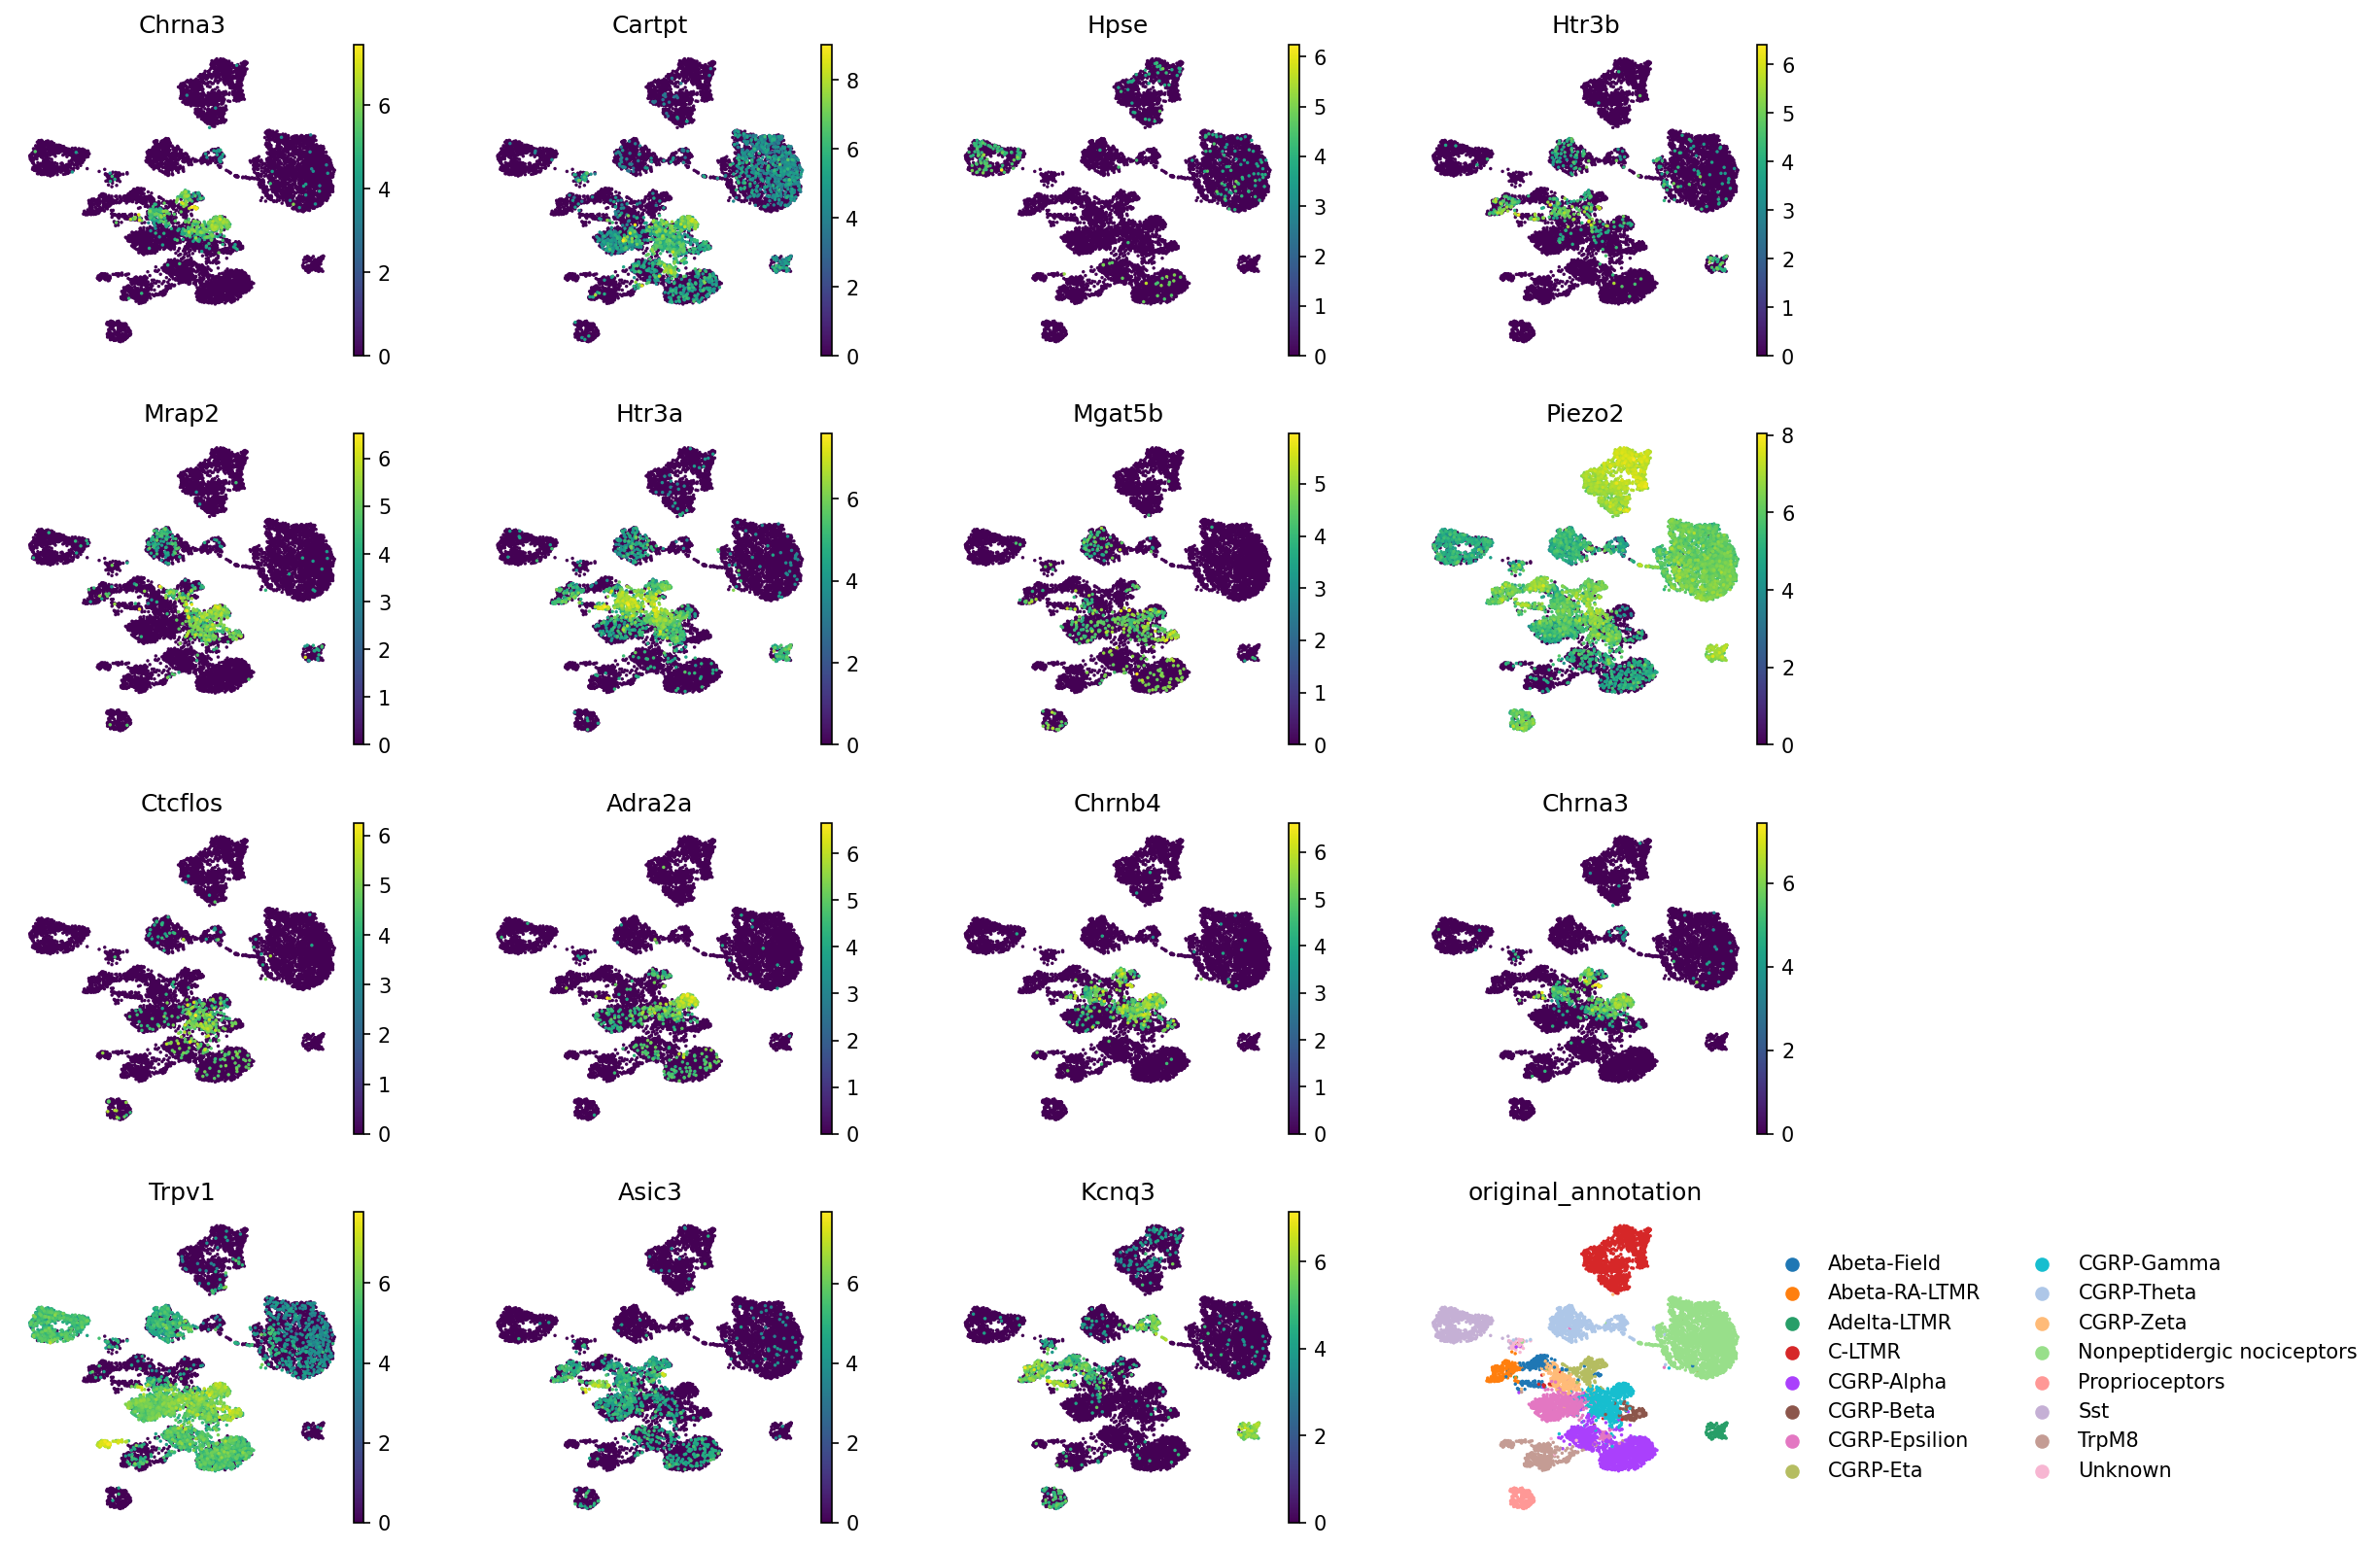

In [40]:
sc.pl.umap(adata, color = genes, frameon = False)

In [41]:
import scanpy as sc

# --- 1. Define your gene list ---
dual_signature_genes = [
    "Chrna3", "Cartpt", "Hpse", "Htr3b", "Mrap2",
    "Htr3a", "Mgat5b", "Chrnb4", "Ntrk2", "Pou4f2"
]

# --- 2. Filter to genes that are actually present in the dataset ---
genes_present = [g for g in dual_signature_genes if g in adata.var_names]

print(f"Using {len(genes_present)} / {len(dual_signature_genes)} genes present in adata:")
print(genes_present)

# --- 3. Score the gene set ---
sc.tl.score_genes(
    adata,
    gene_list=genes_present,
    score_name="dual_positive_signature_score"
)

print("\nAdded adata.obs['dual_positive_signature_score']")

Using 10 / 10 genes present in adata:
['Chrna3', 'Cartpt', 'Hpse', 'Htr3b', 'Mrap2', 'Htr3a', 'Mgat5b', 'Chrnb4', 'Ntrk2', 'Pou4f2']

Added adata.obs['dual_positive_signature_score']


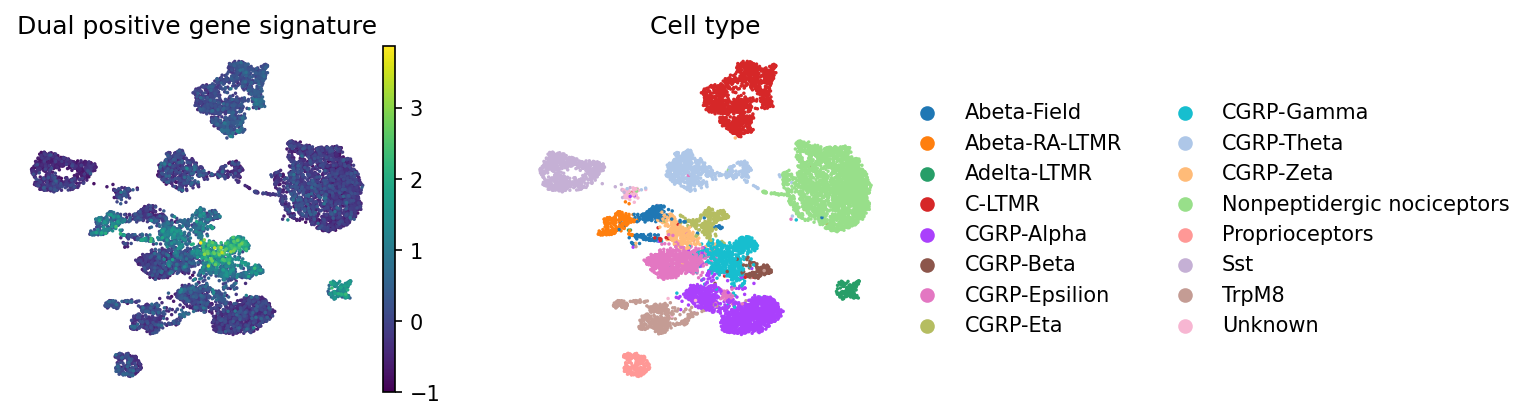

In [42]:
sc.pl.umap(adata, color = ['dual_positive_signature_score', 'original_annotation'], frameon = False, title = ['Dual positive gene signature', 'Cell type'])

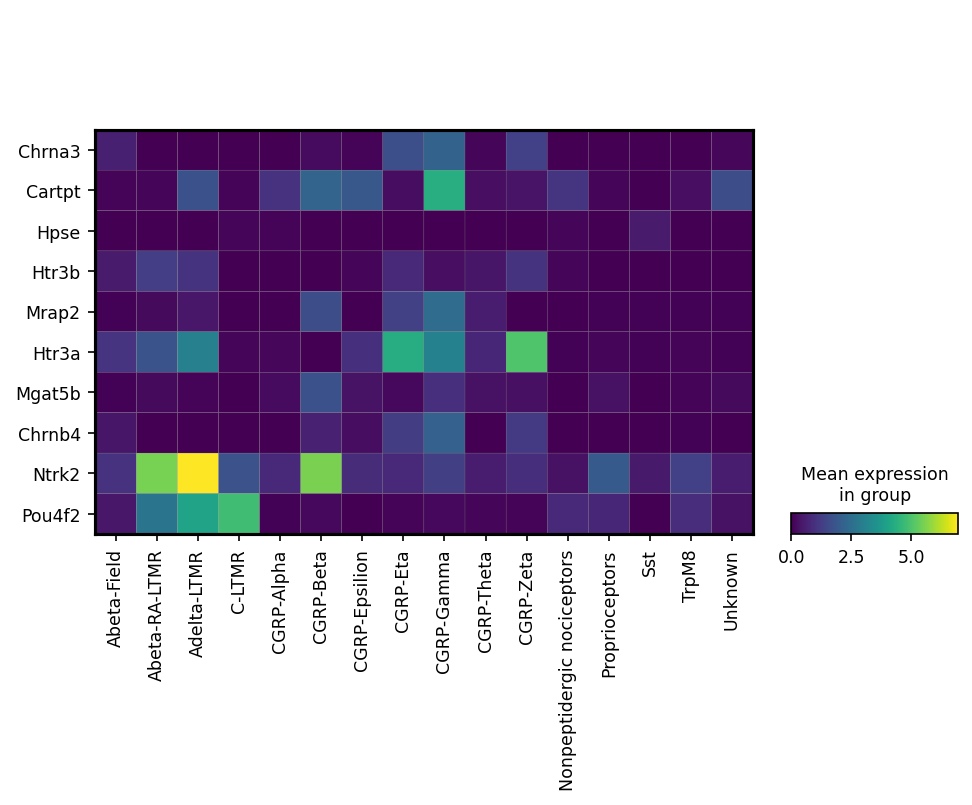

In [43]:
sc.pl.matrixplot(adata, var_names = dual_signature_genes, groupby = 'original_annotation', swap_axes = True, standard_scale = True)

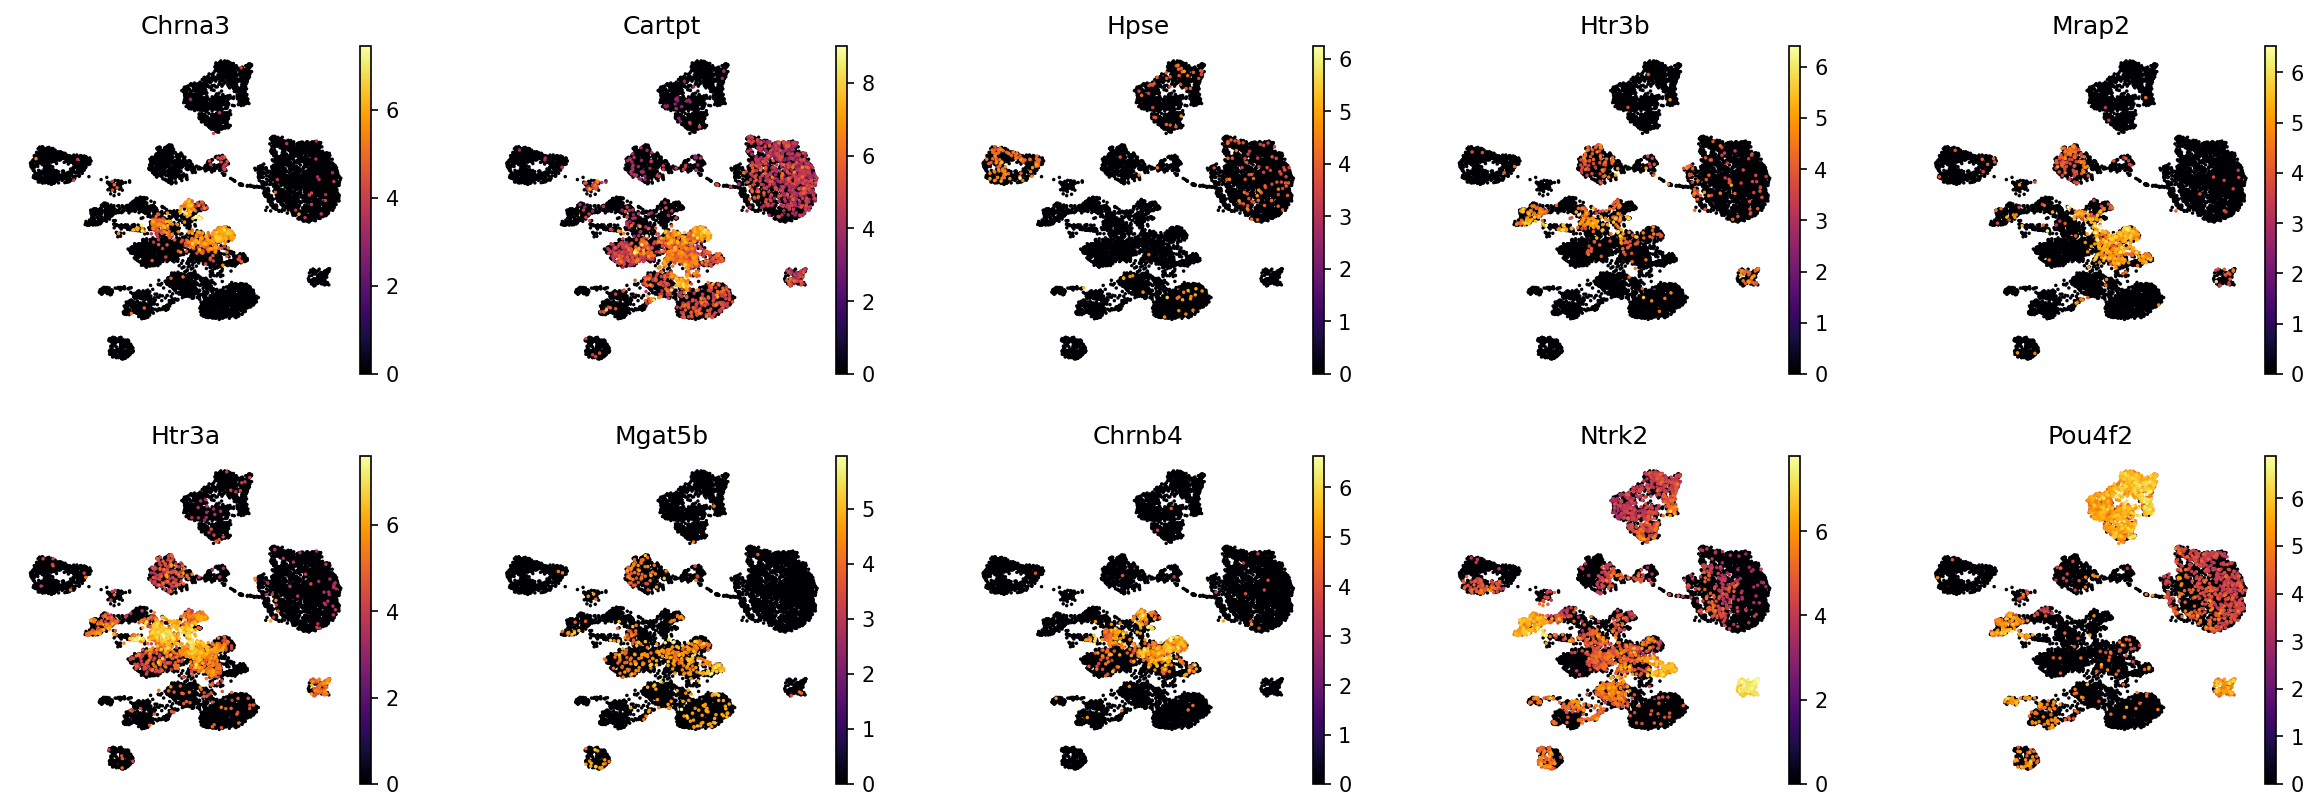

In [44]:
sc.pl.umap(adata, color = [
    "Chrna3", "Cartpt", "Hpse", "Htr3b", "Mrap2",
    "Htr3a", "Mgat5b", "Chrnb4", "Ntrk2", "Pou4f2"], ncols = 5, cmap = 'inferno', frameon = False, show=False)
plt.savefig(os.path.join(plot_out_dir, f"ginty_reference_genes.pdf"), format='pdf', bbox_inches='tight')

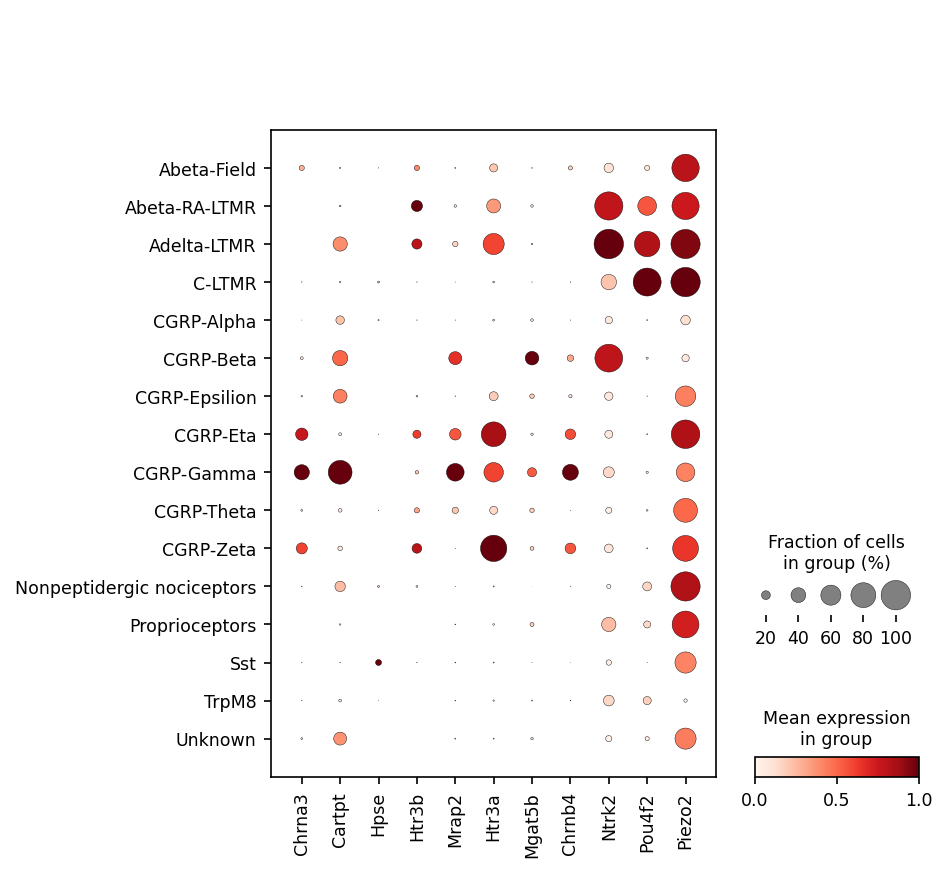

In [45]:
sc.pl.dotplot(adata, var_names = [
    "Chrna3", "Cartpt", "Hpse", "Htr3b", "Mrap2",
    "Htr3a", "Mgat5b", "Chrnb4", "Ntrk2", "Pou4f2", 'Piezo2'
], groupby = 'original_annotation', standard_scale = 'var')

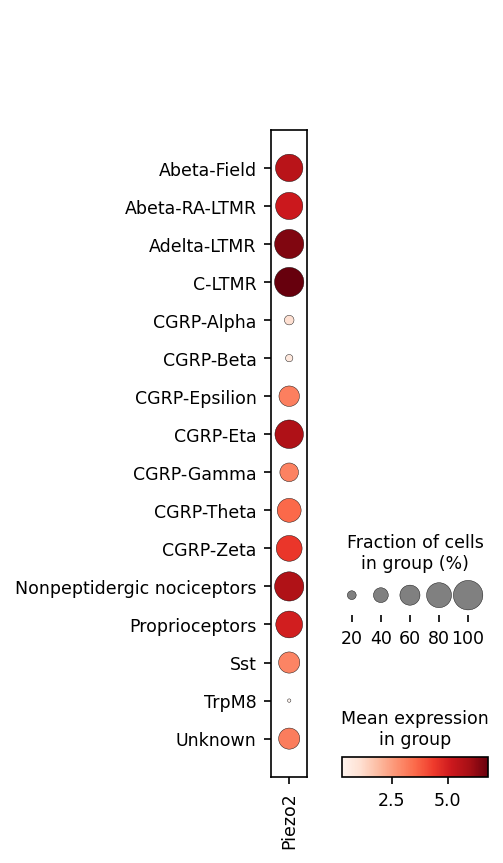

In [46]:
sc.pl.dotplot(adata, var_names = 'Piezo2', groupby = 'original_annotation')

/home/workspace/environment/sc-scvi/lib/python3.12/site-packages/scanpy/plotting/_anndata.py:928: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.violinplot(
/tmp/ipykernel_2044/3003100743.py:75: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


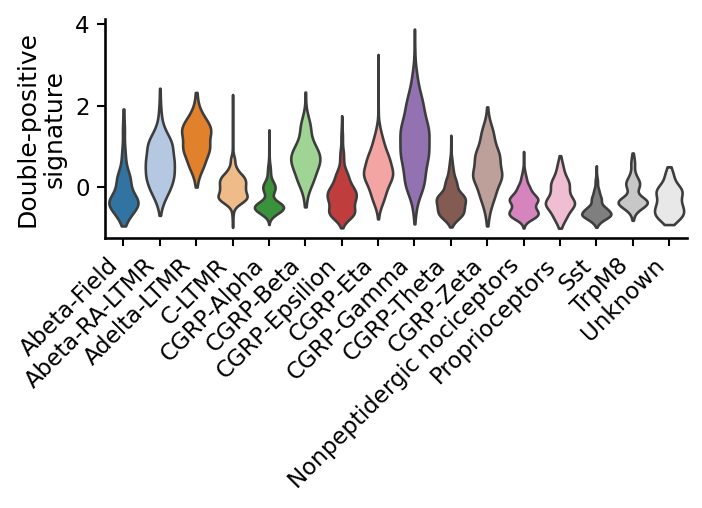

In [47]:
import matplotlib.pyplot as plt
import seaborn as sns

# ---------------------------
# Minimal clean theme
# ---------------------------
sns.set_theme(style="white")

plt.rcParams['figure.figsize'] = (5, 2)   # <-- ONLY CHANGE (shorter height)
plt.rcParams['axes.edgecolor'] = 'black'
plt.rcParams['axes.spines.left'] = True
plt.rcParams['axes.spines.bottom'] = True
plt.rcParams['axes.spines.top'] = False
plt.rcParams['axes.spines.right'] = False
plt.rcParams['axes.labelsize'] = 12

# ---------------------------
# Generate violin without showing
# ---------------------------
ax = sc.pl.violin(
    adata,
    keys='dual_positive_signature_score',
    groupby='original_annotation',
    palette = neuron_label_palette_mapped_ginty,
    stripplot=False,
    jitter=False,
    inner=None,
    show=False
)

# ---------------------------
# Force visible ticks + labels
# ---------------------------
ax.tick_params(
    axis='x',
    which='both',
    bottom=True,
    top=False,
    length=4,
    width=1,
    color='black',
    labelcolor='black'
)

ax.tick_params(
    axis='y',
    which='both',
    left=True,
    right=False,
    length=4,
    width=1,
    color='black',
    labelcolor='black'
)

# ---------------------------
# Fix xtick labels (rotation + color)
# ---------------------------
xticklabels = [t.get_text() for t in ax.get_xticklabels()]
ax.set_xticks(range(len(xticklabels)))
ax.set_xticklabels(
    xticklabels,
    rotation=45,
    ha='right',
    color='black'
)

# ---------------------------
# Labels
# ---------------------------
ax.set_ylabel("Double-positive\nsignature", fontsize=12, color='black')
ax.set_xlabel("")

sns.despine()
plt.tight_layout()
# save
plt.savefig(os.path.join(plot_out_dir, f"ginty_reference_signature_violin.pdf"), format='pdf', bbox_inches='tight')

plt.show()

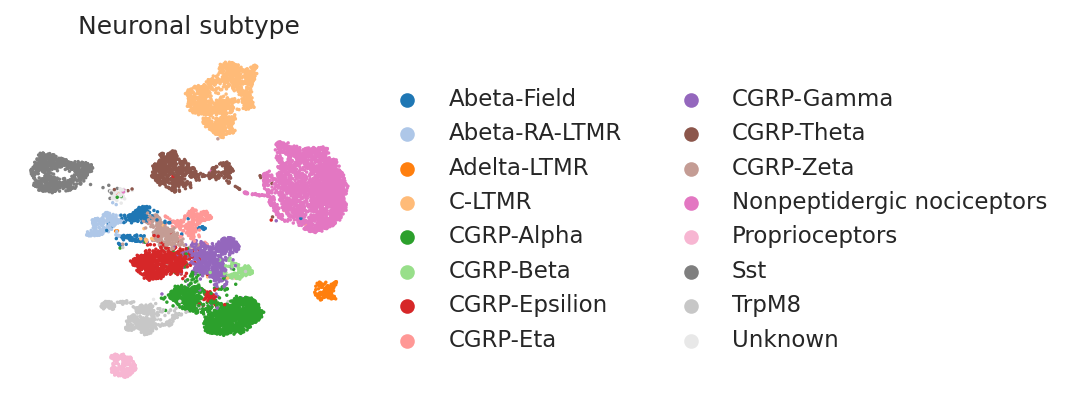

In [48]:
plt.rcParams['figure.figsize'] = (3, 3)
sc.pl.umap(adata, color = ['original_annotation'], frameon = False, title = ['Neuronal subtype'], palette = neuron_label_palette_mapped_ginty)#, legend_loc = 'none')

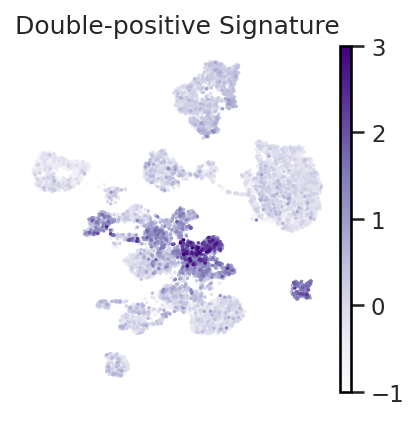

In [51]:
sc.pl.umap(adata, color = ['dual_positive_signature_score'], frameon = False, title = ['Double-positive Signature'], cmap = 'Purples', 
           vmax = 3, 
           show=False)
plt.savefig(os.path.join(plot_out_dir, f"ginty_reference_doublepositive_signature.pdf"), format='pdf', bbox_inches='tight')